In [1]:
from typing import List
from datetime import date
from sqlalchemy import String, Integer, ForeignKey, DECIMAL, Date
from sqlalchemy.orm import DeclarativeBase, Mapped, mapped_column, relationship
from sqlalchemy import create_engine, inspect, select
from sqlalchemy.orm import Session
from sqlalchemy import inspect
from sqlalchemy import text
import os
from pathlib import Path
import pandas as pd
from dotenv import load_dotenv
from adbc_driver_postgresql import dbapi
import pandas as pd
import os
import plotly.express as px
import plotly.io as pio
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
from matplotlib.ticker import ScalarFormatter
from matplotlib import ticker
import seaborn as sns 
from collections import Counter
import numpy as np
import seaborn as sns
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pypq
import pyarrow.csv as pycsv
import textwrap 
from time import time 


sns.set_theme(context='talk', palette='pastel')
plt.rcParams.update({
    'font.family': 'PT Sans',
    'font.size': 25
})

# Define the path to the font file you just placed in your directory
font_path = 'PTSans-Regular.ttf' # Update this if the filename is slightly different

# Check if the file is there, then forcefully add it to Matplotlib
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    print("Success: PT Sans forcefully loaded into Matplotlib!")
else:
    print(f"Error: Could not find {font_path}. Make sure it is in the same folder as this notebook.")

# Now set your rcParams as you normally would
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['PT Sans', 'Arial']

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)
#pd.options.plotting.backend = 'plotly'
pio.templates.default = 'plotly_dark+presentation'

# --- Configuration ---
BASE_DIR = Path('./')
ENV_PATH = Path().cwd().parent/"creds.env"
load_dotenv(dotenv_path=ENV_PATH)

DB_USER = os.getenv("DB_USER", "postgres")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_NAME = os.getenv("DB_NAME", "unarxive")

CONNECTION_STRING = f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}/{DB_NAME}"
engine = create_engine(CONNECTION_STRING)

Success: PT Sans forcefully loaded into Matplotlib!


In [2]:
# Define the path to the font file you just placed in your directory
font_path = 'PTSans-Regular.ttf' # Update this if the filename is slightly different

# Check if the file is there, then forcefully add it to Matplotlib
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    print("Success: PT Sans forcefully loaded into Matplotlib!")
else:
    print(f"Error: Could not find {font_path}. Make sure it is in the same folder as this notebook.")

# Now set your rcParams as you normally would
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['PT Sans', 'Arial']

Success: PT Sans forcefully loaded into Matplotlib!


In [3]:
# some helper functions 
def read_parquet(path, engine='pyarrow', columns=None, convert_dtypes=True, **args):
    """
    Read a parquet file (or a directory of parquet files) 
    columns: list of columns to read, by default, read all columns
    convert_dtypes: if True, convert datatypes to save RAM (takes extra time)
    """
    
    path = Path(path)
    name = path.stem 
    column_st = 'columns="all"' if columns is None else f'{columns=!r}'
    print(f'\nReading {column_st} from {path!r} using {engine=!r}.')

    tic = time()
    df = pd.read_parquet(path, engine=engine, columns=columns, **args)
    toc = time()
    print(f'Read {len(df):,} rows from {path.stem!r} in {toc-tic:.2f} sec.')
    
    if convert_dtypes:
        tic = time()
        size_before = df.memory_usage(deep=True).sum() / 1024 / 1024 / 1024

        string_cols_d = {}
        for col, dtype in df.dtypes.to_dict().items():
            if dtype == 'object':  # convert object columns to string
                string_cols_d[col] = 'string[python]'
            if col == 'type' or col == 'concept_name':
                if dtype != 'category':
                    string_cols_d[col] = 'category'
            if col == 'publication_month':
                if dtype != 'uint8':
                    string_cols_d[col] = 'uint8'
            if col == 'score':
                if dtype != 'float16':
                    string_cols_d[col] = 'float16'
        # print(f'{string_cols_d=}')
        df = df.astype(string_cols_d) 
        
        size_after = df.memory_usage(deep=True).sum() / 1024 / 1024 / 1024
        toc = time()
        print(f'Converting dtypes took {toc-tic:.2f} sec. Size before: {size_before:.2f}GB, after: {size_after:.2f}GB.')
    
    display('Top 3 rows:', df.head(3))
    return df


def peek_parquet(path):
    """
    peeks at a parquet file (or a directory containing parquet files) without reading the whole thing and prints the following:
    * Path
    * schema
    * number of pieces (fragments)
    * number of rows 
    """

    path = Path(path)
    parq_file = pypq.ParquetDataset(path)
    piece_count = len(parq_file.fragments)
    schema = textwrap.indent(parq_file.schema.to_string(), ' '*4)
    row_count = sum(frag.count_rows() for frag in parq_file.fragments)
    if Path(path).is_dir():
      size = sum(Path(frag.path).stat().st_size for frag in parq_file.fragments)
    else:
      size = path.stat().st_size
    
    st = [
        f'Name: {path.stem!r}',  
        f'Path: {str(path)!r}',
        f'Size: {size/1024/1024/1024:.2g} GB',
        f'Files: {piece_count:,}',
        f'Rows: {row_count:,}',
        f'Schema:\n{schema}',
        f'5 random rows:',
    ]
    print('\n'.join(st))
    sample_df = parq_file.fragments[0].head(5).to_pandas()  # read 5 rows from the first fragment
    display(sample_df)

    return

def read_smaller_tables(name):
    """
    Some smaller tables exist as a CSV only
    """
    assert name in ['institutions', 'institutions_geo', 'concepts']
    path = basepath / 'csv-files'/ month / name
    df = pd.read_csv(f'{path}.csv.gz', engine='c')
    return df

In [4]:
def run_query(query: str, engine=engine) -> pd.DataFrame:
  return pd.read_sql(query, engine)

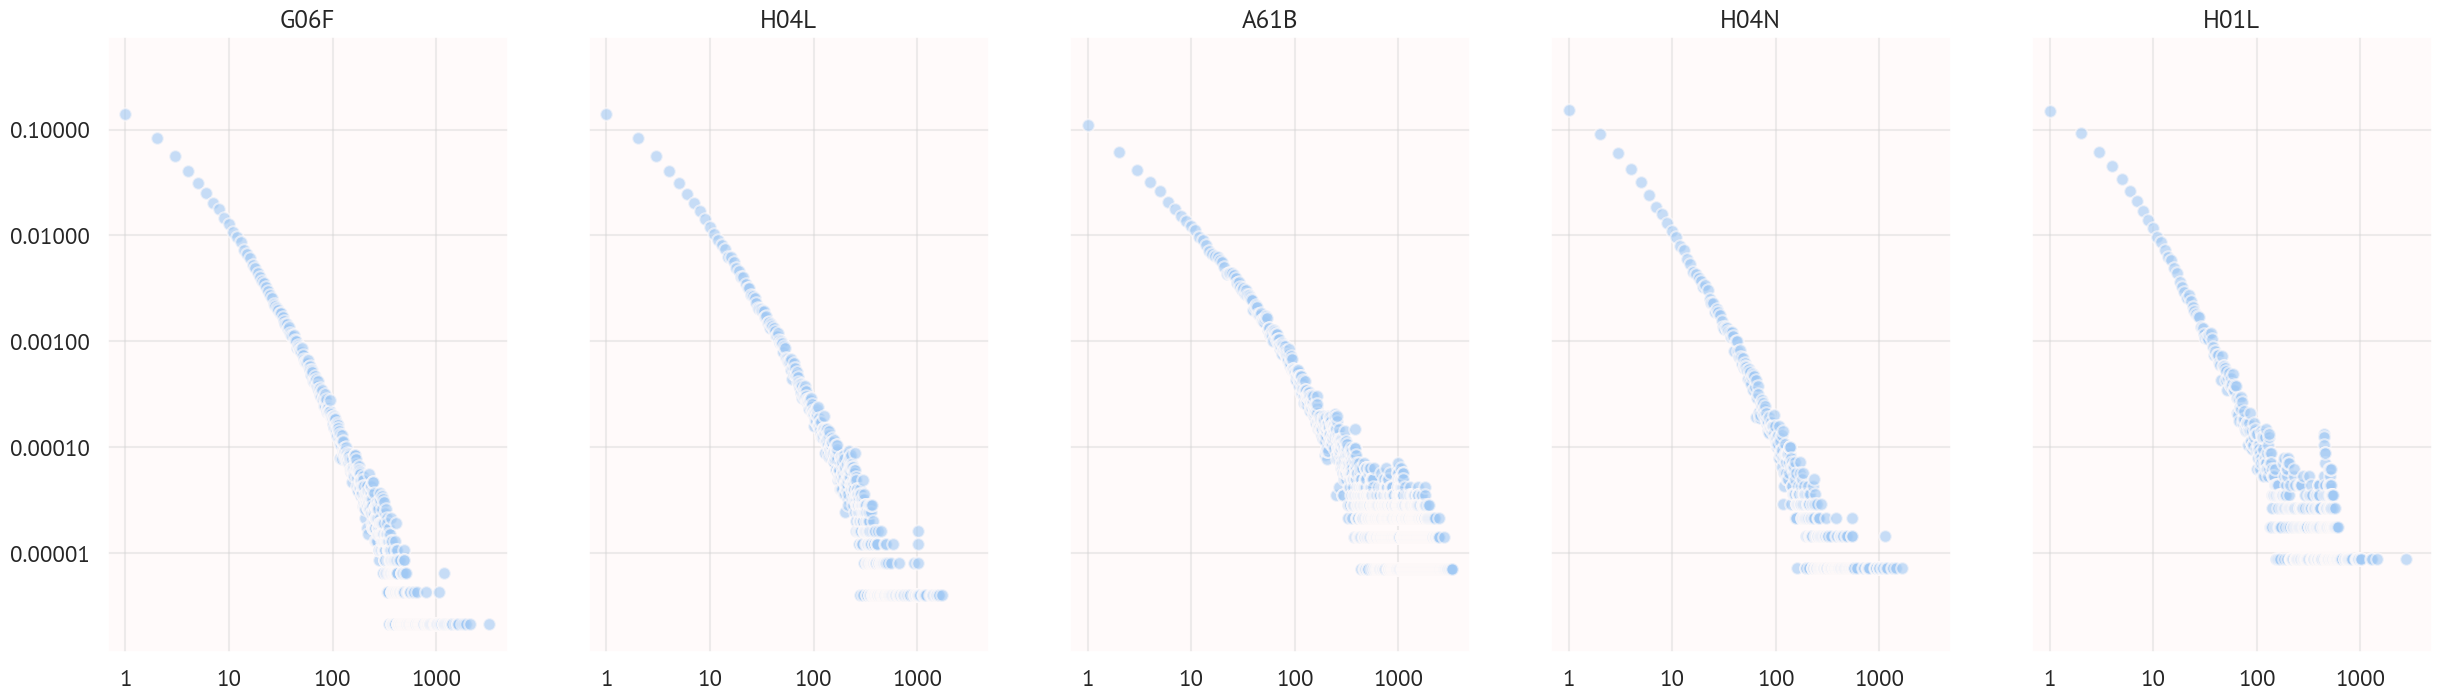

In [7]:
degree_with_cpc_df = pd.read_parquet('../parquets/patents_degree_info_2_2005.parquet')

top_subclasses = (
    degree_with_cpc_df
    .cpc_subclass
    .value_counts()
    .head(5)
    .index
    .tolist()
)
fig, axs = plt.subplots(figsize=(30, 8), ncols=len(top_subclasses), sharex=True, sharey=True)

for subclass, ax in zip(top_subclasses, axs):
    subset = degree_with_cpc_df[degree_with_cpc_df.cpc_subclass == subclass]
    counts = Counter(subset.num_citations)
    total = sum(counts.values())
    norm_counts = {k: v / total for k, v in counts.items()}
    
    X = sorted(norm_counts.keys())
    Y = [norm_counts[x] for x in X]
    
    ax.set_facecolor('snow')
    ax.grid(alpha=.4, color='lightgrey')
    ax.scatter(X, Y, label=subclass, alpha=0.6, edgecolors='snow')
    ax.set_title(subclass)
    ax.set_xscale('log')
    ax.set_yscale('log')
    for axis in [ax.xaxis, ax.yaxis]:
        formatter = ScalarFormatter()
        formatter.set_scientific(False)
        axis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.5f}"))
# ax.set_xlabel('In-degree (Citations)')
# ax.set_ylabel('Proportion')
# ax.set_title('In-degree distribution by CPC subclass (log-log)')
# ax.legend()
#fig.savefig('../figures/indegree_by_subclass_loglog.png', dpi=300, bbox_inches='tight', transparent=True)

In [3]:
print(Path.cwd())

NameError: name 'Path' is not defined

In [14]:
sql = """
SELECT cpc_subclass, cpc_subclass_title, cpc_class, cpc_class_title
FROM g_cpc_title;
"""

cpc_title_df = pd.read_sql(text(sql), engine)
cpc_title_df

,cpc_subclass,cpc_subclass_title,cpc_class,cpc_class_title
0,A01B,SOIL WORKING IN AGRICULTURE OR FORESTRY; PARTS...,A01,AGRICULTURE; FORESTRY; ANIMAL HUSBANDRY; HUNTI...
1,A01B,SOIL WORKING IN AGRICULTURE OR FORESTRY; PARTS...,A01,AGRICULTURE; FORESTRY; ANIMAL HUSBANDRY; HUNTI...
2,A01B,SOIL WORKING IN AGRICULTURE OR FORESTRY; PARTS...,A01,AGRICULTURE; FORESTRY; ANIMAL HUSBANDRY; HUNTI...
3,A01B,SOIL WORKING IN AGRICULTURE OR FORESTRY; PARTS...,A01,AGRICULTURE; FORESTRY; ANIMAL HUSBANDRY; HUNTI...
4,A01B,SOIL WORKING IN AGRICULTURE OR FORESTRY; PARTS...,A01,AGRICULTURE; FORESTRY; ANIMAL HUSBANDRY; HUNTI...
...,...,...,...,...
269512,Y10T,TECHNICAL SUBJECTS COVERED BY FORMER US CLASSI...,Y10,TECHNICAL SUBJECTS COVERED BY FORMER USPC
269513,Y10T,TECHNICAL SUBJECTS COVERED BY FORMER US CLASSI...,Y10,TECHNICAL SUBJECTS COVERED BY FORMER USPC
269514,Y10T,TECHNICAL SUBJECTS COVERED BY FORMER US CLASSI...,Y10,TECHNICAL SUBJECTS COVERED BY FORMER USPC
269515,Y10T,TECHNICAL SUBJECTS COVERED BY FORMER US CLASSI...,Y10,TECHNICAL SUBJECTS COVERED BY FORMER USPC


In [8]:

(
    cpc_title_df
    .query("cpc_subclass.isin(@top_subclasses)")
    .drop_duplicates()
)

,cpc_subclass,cpc_subclass_title,cpc_class,cpc_class_title
11357,A61B,DIAGNOSIS; SURGERY; IDENTIFICATION,A61,MEDICAL OR VETERINARY SCIENCE; HYGIENE
153120,G06F,ELECTRIC DIGITAL DATA PROCESSING,G06,COMPUTING OR CALCULATING; COUNTING
217376,H01L,SEMICONDUCTOR DEVICES NOT COVERED BY CLASS H10,H01,ELECTRIC ELEMENTS
240054,H04L,"TRANSMISSION OF DIGITAL INFORMATION, e.g. TELE...",H04,ELECTRIC COMMUNICATION TECHNIQUE
241724,H04N,"PICTORIAL COMMUNICATION, e.g. TELEVISION",H04,ELECTRIC COMMUNICATION TECHNIQUE


In [9]:
import matplotlib.colors as mcolors
for color in mcolors.CSS4_COLORS:
    print(color)

aliceblue
antiquewhite
aqua
aquamarine
azure
beige
bisque
black
blanchedalmond
blue
blueviolet
brown
burlywood
cadetblue
chartreuse
chocolate
coral
cornflowerblue
cornsilk
crimson
cyan
darkblue
darkcyan
darkgoldenrod
darkgray
darkgreen
darkgrey
darkkhaki
darkmagenta
darkolivegreen
darkorange
darkorchid
darkred
darksalmon
darkseagreen
darkslateblue
darkslategray
darkslategrey
darkturquoise
darkviolet
deeppink
deepskyblue
dimgray
dimgrey
dodgerblue
firebrick
floralwhite
forestgreen
fuchsia
gainsboro
ghostwhite
gold
goldenrod
gray
green
greenyellow
grey
honeydew
hotpink
indianred
indigo
ivory
khaki
lavender
lavenderblush
lawngreen
lemonchiffon
lightblue
lightcoral
lightcyan
lightgoldenrodyellow
lightgray
lightgreen
lightgrey
lightpink
lightsalmon
lightseagreen
lightskyblue
lightslategray
lightslategrey
lightsteelblue
lightyellow
lime
limegreen
linen
magenta
maroon
mediumaquamarine
mediumblue
mediumorchid
mediumpurple
mediumseagreen
mediumslateblue
mediumspringgreen
mediumturquoise
mediumv

In [22]:
degree_with_cpc_df = pd.read_parquet('../parquets/patents_degree_info_2_2005.parquet')
degree_with_cpc_df

,patent_id,num_references,year,num_citations,cpc_class,cpc_subclass
0,10000000,2,2018,19.0,G01,G01S
1,10000001,6,2018,0.0,B29,B29C
2,10000002,3,2018,0.0,B29,B29C
3,10000003,4,2018,2.0,B29,B29C
4,10000004,2,2018,0.0,B29,B29C
...,...,...,...,...,...,...
4882287,9999995,6,2018,0.0,B29,B29C
4882288,9999996,4,2018,2.0,B29,B29C
4882289,9999997,14,2018,0.0,B29,B29C
4882290,9999998,1,2018,0.0,B29,B29C


In [23]:
sql = """
SELECT cpc_subclass, cpc_subclass_title, cpc_class, cpc_class_title
FROM g_cpc_title;
"""

cpc_title_df = pd.read_sql(text(sql), engine)
cpc_title_df

,cpc_subclass,cpc_subclass_title,cpc_class,cpc_class_title
0,A01B,SOIL WORKING IN AGRICULTURE OR FORESTRY; PARTS...,A01,AGRICULTURE; FORESTRY; ANIMAL HUSBANDRY; HUNTI...
1,A01B,SOIL WORKING IN AGRICULTURE OR FORESTRY; PARTS...,A01,AGRICULTURE; FORESTRY; ANIMAL HUSBANDRY; HUNTI...
2,A01B,SOIL WORKING IN AGRICULTURE OR FORESTRY; PARTS...,A01,AGRICULTURE; FORESTRY; ANIMAL HUSBANDRY; HUNTI...
3,A01B,SOIL WORKING IN AGRICULTURE OR FORESTRY; PARTS...,A01,AGRICULTURE; FORESTRY; ANIMAL HUSBANDRY; HUNTI...
4,A01B,SOIL WORKING IN AGRICULTURE OR FORESTRY; PARTS...,A01,AGRICULTURE; FORESTRY; ANIMAL HUSBANDRY; HUNTI...
...,...,...,...,...
269512,Y10T,TECHNICAL SUBJECTS COVERED BY FORMER US CLASSI...,Y10,TECHNICAL SUBJECTS COVERED BY FORMER USPC
269513,Y10T,TECHNICAL SUBJECTS COVERED BY FORMER US CLASSI...,Y10,TECHNICAL SUBJECTS COVERED BY FORMER USPC
269514,Y10T,TECHNICAL SUBJECTS COVERED BY FORMER US CLASSI...,Y10,TECHNICAL SUBJECTS COVERED BY FORMER USPC
269515,Y10T,TECHNICAL SUBJECTS COVERED BY FORMER US CLASSI...,Y10,TECHNICAL SUBJECTS COVERED BY FORMER USPC


In [26]:
cpc_titles = cpc_title_df.drop_duplicates(subset='cpc_subclass')

degree_with_cpc_titles_df = degree_with_cpc_df.merge(
    cpc_titles[['cpc_subclass', 'cpc_subclass_title', 'cpc_class_title']],
    on='cpc_subclass',
    how='inner'
)

In [27]:
degree_with_cpc_titles_df.to_parquet('../parquets/dfwithcpctitles.parquet')

In [14]:
import matplotlib.font_manager as fm
sorted(set(f.name for f in fm.fontManager.ttflist))

['AR PL UKai CN',
 'AR PL UMing CN',
 'Andale Mono',
 'Arial',
 'Arial Black',
 'C059',
 'Comic Sans MS',
 'Courier New',
 'D050000L',
 'DejaVu Math TeX Gyre',
 'DejaVu Sans',
 'DejaVu Sans Display',
 'DejaVu Sans Mono',
 'DejaVu Serif',
 'DejaVu Serif Display',
 'Droid Sans Fallback',
 'Georgia',
 'Impact',
 'Latin Modern Math',
 'Latin Modern Mono',
 'Latin Modern Mono Caps',
 'Latin Modern Mono Light',
 'Latin Modern Mono Light Cond',
 'Latin Modern Mono Prop',
 'Latin Modern Mono Prop Light',
 'Latin Modern Mono Slanted',
 'Latin Modern Roman',
 'Latin Modern Roman Caps',
 'Latin Modern Roman Demi',
 'Latin Modern Roman Dunhill',
 'Latin Modern Roman Slanted',
 'Latin Modern Roman Unslanted',
 'Latin Modern Sans',
 'Latin Modern Sans Demi Cond',
 'Latin Modern Sans Quotation',
 'Lato',
 'Liberation Mono',
 'Liberation Sans',
 'Liberation Sans Narrow',
 'Liberation Serif',
 'Nimbus Mono PS',
 'Nimbus Roman',
 'Nimbus Sans',
 'Nimbus Sans Narrow',
 'Noto Kufi Arabic',
 'Noto Looped L

In [19]:
degree_with_cpc_df

NameError: name 'degree_with_cpc_df' is not defined

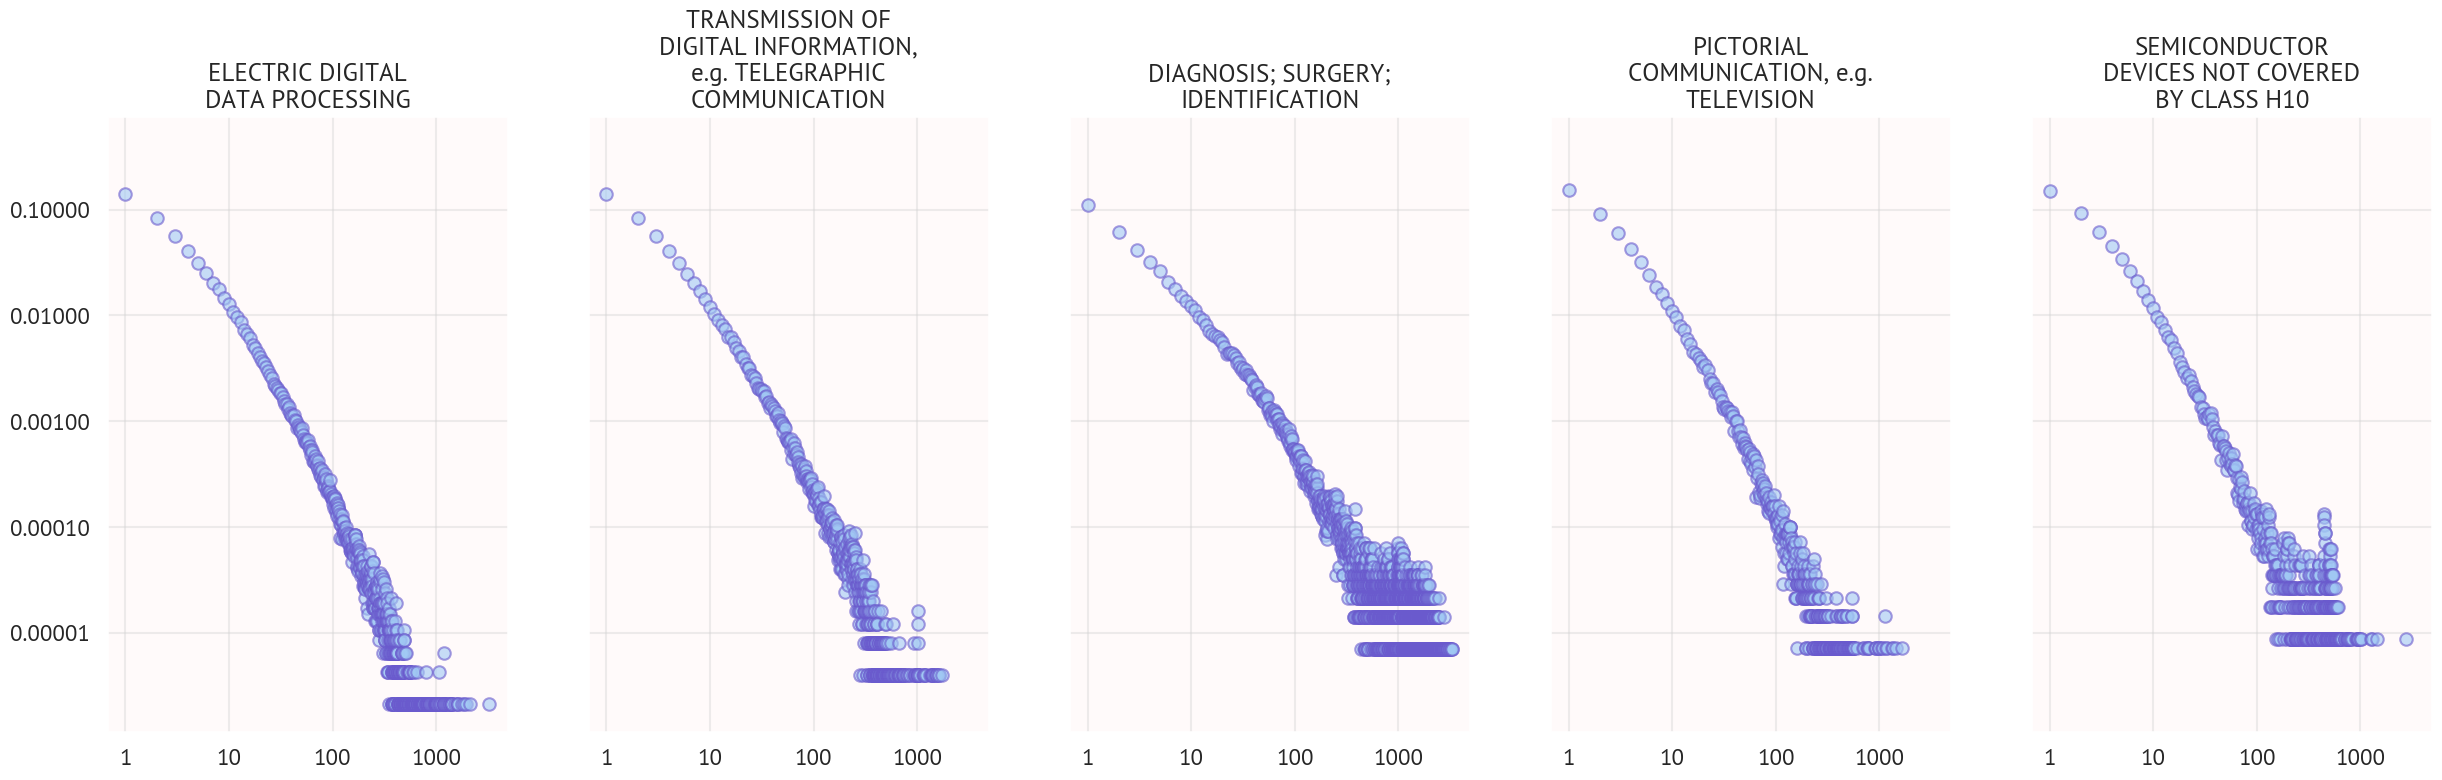

In [26]:
degree_with_cpc_df

top_subclasses = (
    degree_with_cpc_df
    .cpc_subclass
    .value_counts()
    .head(5)
    .index
    .tolist()
)
fig, axs = plt.subplots(figsize=(30, 8), ncols=len(top_subclasses), sharex=True, sharey=True)

for subclass, ax in zip(top_subclasses, axs):
    subset = degree_with_cpc_df[degree_with_cpc_df.cpc_subclass == subclass]
    counts = Counter(subset.num_citations)
    total = sum(counts.values())
    norm_counts = {k: v / total for k, v in counts.items()}
    
    X = sorted(norm_counts.keys())
    Y = [norm_counts[x] for x in X]

    title = textwrap.fill(subset.cpc_subclass_title.iloc[0], width=20)

    ax.set_facecolor('snow')
    ax.grid(alpha=.4, color='lightgrey')
    ax.scatter(X, Y, label=subclass, alpha=0.6, edgecolors='slateblue')
    ax.set_title(title)
    ax.set_xscale('log')
    ax.set_yscale('log')
    for axis in [ax.xaxis, ax.yaxis]:
        formatter = ScalarFormatter()
        formatter.set_scientific(False)
        axis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.5f}"))
# ax.set_xlabel('In-degree (Citations)')
# ax.set_ylabel('Proportion')
# ax.set_title('In-degree distribution by CPC subclass (log-log)')
# ax.legend()

fig.savefig('../figures/cpc_subclasstitles.png', dpi=300, bbox_inches='tight', transparent=True)



In [11]:
degree_with_cpc_df

,patent_id,num_references,year,num_citations,cpc_class,cpc_subclass
0,10000000,2,2018,19.0,G01,G01S
1,10000001,6,2018,0.0,B29,B29C
2,10000002,3,2018,0.0,B29,B29C
3,10000003,4,2018,2.0,B29,B29C
4,10000004,2,2018,0.0,B29,B29C
...,...,...,...,...,...,...
4882287,9999995,6,2018,0.0,B29,B29C
4882288,9999996,4,2018,2.0,B29,B29C
4882289,9999997,14,2018,0.0,B29,B29C
4882290,9999998,1,2018,0.0,B29,B29C


In [18]:
degree_with_cpc_df.sort_values('num_citations', ascending=False).head(5)

,patent_id,num_references,year,num_citations,cpc_class,cpc_subclass,cpc_subclass_title,cpc_class_title
2793569,7674650,28,2010,4311.0,H10,H10D,INORGANIC ELECTRIC SEMICONDUCTOR DEVICES,SEMICONDUCTOR DEVICES; ELECTRIC SOLID-STATE DE...
2202470,7061014,10,2006,4054.0,H10,H10D,INORGANIC ELECTRIC SEMICONDUCTOR DEVICES,SEMICONDUCTOR DEVICES; ELECTRIC SOLID-STATE DE...
2848973,7732819,28,2010,4033.0,H10,H10D,INORGANIC ELECTRIC SEMICONDUCTOR DEVICES,SEMICONDUCTOR DEVICES; ELECTRIC SOLID-STATE DE...
2432168,7297977,6,2007,4024.0,H10,H10D,INORGANIC ELECTRIC SEMICONDUCTOR DEVICES,SEMICONDUCTOR DEVICES; ELECTRIC SOLID-STATE DE...
2417478,7282782,7,2007,3974.0,H10,H10D,INORGANIC ELECTRIC SEMICONDUCTOR DEVICES,SEMICONDUCTOR DEVICES; ELECTRIC SOLID-STATE DE...


In [19]:
sql = """
SELECT citation_patent_id, COUNT(c.patent_id) as num_citations
FROM g_us_patent_citation c
JOIN g_patent p1 ON c.patent_id = p1.patent_id
JOIN g_patent p2 ON c.citation_patent_id = p2.patent_id
WHERE EXTRACT(YEAR FROM p1.patent_date) > 2004
  AND EXTRACT(YEAR FROM p2.patent_date) > 2004
GROUP BY citation_patent_id
ORDER BY num_citations DESC
LIMIT 5;
"""
pd.read_sql(text(sql), engine)

,citation_patent_id,num_citations
0,7674650,4311
1,7061014,4054
2,7732819,4033
3,7297977,4024
4,7282782,3974


In [20]:

sql= """
SELECT *
FROM g_patent p
JOIN g_assignee_disambiguated a ON p.patent_id = a.patent_id
JOIN g_inventor_disambiguated i ON p.patent_id = i.patent_id
JOIN g_location_disambiguated l ON i.location_id = l.location_id
WHERE p.patent_id IN ('7674650', '7061014', '7732819', '7297977', '7282782');

"""

pd.read_sql(text(sql), engine)

,patent_id,patent_type,patent_date,patent_title,wipo_kind,num_claims,withdrawn,filename,patent_id,assignee_sequence,assignee_id,disambig_assignee_individual_name_first,disambig_assignee_individual_name_last,disambig_assignee_organization,assignee_type,location_id,patent_id,inventor_sequence,inventor_id,disambig_inventor_name_first,disambig_inventor_name_last,gender_code,location_id,location_id,disambig_city,disambig_state,disambig_country,latitude,longitude,county,state_fips,county_fips
0,7061014,utility,2006-06-13,Natural-superlattice homologous single crystal...,B2,12,0,ipg060613.xml,7061014,0,eb2ebb85-8503-414d-9730-aed37c7ab928,None,None,Japan Science and Technology Agency,3.0,a430f863-16c8-11ed-9b5f-1234bde3cd05,7061014,5,fl:to_ln:kamiya-6,Toshio,Kamiya,M,1d2251c8-16c8-11ed-9b5f-1234bde3cd05,1d2251c8-16c8-11ed-9b5f-1234bde3cd05,Yokohama,None,JP,35.444991,139.636768,None,NaN,NaN
1,7297977,utility,2007-11-20,Semiconductor device,B2,32,0,ipg071120.xml,7297977,0,88288889-fbea-42ef-818c-62d683c90767,None,None,"HEWLETT-PACKARD DEVELOPMENT COMPANY, L.P.",2.0,4e49a0a0-16c8-11ed-9b5f-1234bde3cd05,7297977,2,fl:pe_ln:mardilovich-1,Peter,Mardilovich,M,c4358674-16c7-11ed-9b5f-1234bde3cd05,c4358674-16c7-11ed-9b5f-1234bde3cd05,Corvallis,OR,US,44.564566,-123.262044,Benton,41.0,3.0
2,7674650,utility,2010-03-09,Semiconductor device and manufacturing method ...,B2,28,0,ipg100309.xml,7674650,0,3cbd0e04-001d-46a5-986d-456478d9e140,None,None,"Semiconductor Energy Laboratory Co., Ltd.",3.0,7159b2a8-16c8-11ed-9b5f-1234bde3cd05,7674650,2,fl:no_ln:sone-5,Norihito,Sone,M,1d2251c8-16c8-11ed-9b5f-1234bde3cd05,1d2251c8-16c8-11ed-9b5f-1234bde3cd05,Yokohama,None,JP,35.444991,139.636768,None,NaN,NaN
3,7732819,utility,2010-06-08,Semiconductor device and manufacturing method ...,B2,49,0,ipg100608.xml,7732819,0,3cbd0e04-001d-46a5-986d-456478d9e140,None,None,"Semiconductor Energy Laboratory Co., Ltd.",3.0,7159b2a8-16c8-11ed-9b5f-1234bde3cd05,7732819,0,fl:ke_ln:akimoto-8,Kengo,Akimoto,M,1d2251c8-16c8-11ed-9b5f-1234bde3cd05,1d2251c8-16c8-11ed-9b5f-1234bde3cd05,Yokohama,None,JP,35.444991,139.636768,None,NaN,NaN
4,7061014,utility,2006-06-13,Natural-superlattice homologous single crystal...,B2,12,0,ipg060613.xml,7061014,0,eb2ebb85-8503-414d-9730-aed37c7ab928,None,None,Japan Science and Technology Agency,3.0,a430f863-16c8-11ed-9b5f-1234bde3cd05,7061014,0,fl:hi_ln:hosono-6,Hideo,Hosono,M,1d2251c8-16c8-11ed-9b5f-1234bde3cd05,1d2251c8-16c8-11ed-9b5f-1234bde3cd05,Yokohama,None,JP,35.444991,139.636768,None,NaN,NaN
5,7674650,utility,2010-03-09,Semiconductor device and manufacturing method ...,B2,28,0,ipg100309.xml,7674650,0,3cbd0e04-001d-46a5-986d-456478d9e140,None,None,"Semiconductor Energy Laboratory Co., Ltd.",3.0,7159b2a8-16c8-11ed-9b5f-1234bde3cd05,7674650,0,fl:ke_ln:akimoto-8,Kengo,Akimoto,M,1d2251c8-16c8-11ed-9b5f-1234bde3cd05,1d2251c8-16c8-11ed-9b5f-1234bde3cd05,Yokohama,None,JP,35.444991,139.636768,None,NaN,NaN
6,7732819,utility,2010-06-08,Semiconductor device and manufacturing method ...,B2,49,0,ipg100608.xml,7732819,0,3cbd0e04-001d-46a5-986d-456478d9e140,None,None,"Semiconductor Energy Laboratory Co., Ltd.",3.0,7159b2a8-16c8-11ed-9b5f-1234bde3cd05,7732819,1,fl:ta_ln:honda-37,Tatsuya,Honda,M,1d2251c8-16c8-11ed-9b5f-1234bde3cd05,1d2251c8-16c8-11ed-9b5f-1234bde3cd05,Yokohama,None,JP,35.444991,139.636768,None,NaN,NaN
7,7061014,utility,2006-06-13,Natural-superlattice homologous single crystal...,B2,12,0,ipg060613.xml,7061014,0,eb2ebb85-8503-414d-9730-aed37c7ab928,None,None,Japan Science and Technology Agency,3.0,a430f863-16c8-11ed-9b5f-1234bde3cd05,7061014,4,fl:ma_ln:hirano-12,Masahiro,Hirano,M,42f90495-16c8-11ed-9b5f-1234bde3cd05,42f90495-16c8-11ed-9b5f-1234bde3cd05,Tokyo,None,JP,35.682839,139.759455,None,NaN,NaN
8,7674650,utility,2010-03-09,Semiconductor device and manufacturing method ...,B2,28,0,ipg100309.xml,7674650,0,3cbd0e04-001d-46a5-986d-456478d9e140,None,None,"Semiconductor Energy Laboratory Co., Ltd.",3.0,7159b2a8-16c8-11ed-9b5f-1234bde3cd05,7674650,1,f

In [21]:
sql = """
SELECT patent_title
FROM g_patent
WHERE patent_id = '7674650';
"""
pd.read_sql(text(sql), engine)

,patent_title
0,Semiconductor device and manufacturing method ...


In [22]:
sql = """
SELECT

SyntaxError: incomplete input (627457762.py, line 1)

In [32]:
sql2 = """
SELECT l.disambig_state as state, COUNT(c.patent_id) as total_citations_received
FROM g_us_patent_citation c
JOIN g_patent p1 ON c.patent_id = p1.patent_id
JOIN g_patent p2 ON c.citation_patent_id = p2.patent_id
JOIN g_inventor_disambiguated i ON c.citation_patent_id = i.patent_id
JOIN g_location_disambiguated l ON i.location_id = l.location_id
WHERE EXTRACT(YEAR FROM p1.patent_date) > 2004
  AND EXTRACT(YEAR FROM p2.patent_date) > 2004
GROUP BY l.disambig_state
ORDER BY total_citations_received DESC
LIMIT 51;
"""
pd.read_sql(text(sql2), engine)

,state,total_citations_received
0,None,40035514
1,CA,32217236
2,OH,10095896
3,MA,5570915
4,WA,5279899
5,NY,4581317
6,TX,4534645
7,CT,4277071
8,MN,3316599
9,MI,3151251


In [31]:
sql3 = """
SELECT l.disambig_state as state, COUNT(DISTINCT p.patent_id) as num_patents
FROM g_patent p
JOIN g_inventor_disambiguated i ON p.patent_id = i.patent_id
JOIN g_location_disambiguated l ON i.location_id = l.location_id
WHERE EXTRACT(YEAR FROM p.patent_date) > 2004
GROUP BY l.disambig_state
ORDER BY num_patents DESC
LIMIT 51;
"""
pd.read_sql(text(sql3), engine)

,state,num_patents
0,None,3290493
1,CA,943125
2,TX,259876
3,NY,236491
4,MA,192652
5,WA,167706
6,MI,138378
7,IL,137882
8,NJ,137517
9,PA,123788


In [ ]:
sql = """
SELECT COUNT(*)
FROM g_cpc_current

In [ ]:
pd.read_parquet('../parquets/patents_degree_info_2_2005.parquet')

In [ ]:
print(Path.cwd)

In [ ]:
os.chdir('ipynb')

In [ ]:
print(Path().cwd())

In [ ]:
degree_with_cpc_df = pd.read_parquet('../parquets/patents_degree_info_2_2005.parquet')

top_subclasses = (
    degree_with_cpc_df
    .cpc_subclass
    .value_counts()
    .head(5)
    .index
    .tolist()
)

print(top_subclasses)

In [ ]:
sql = """
SELECT DISTINCT cpc_subclass, cpc_subclass_title
FROM g_cpc_title
WHERE cpc_subclass IN ('G06F', 'H04L', 'A61B', 'H04N', 'H01L');
"""
pd.read_sql(text(sql), engine)

In [ ]:
sns.color_palette("pastel")

In [ ]:
import matplotlib.colors as mcolors

palette = sns.color_palette("pastel")
for i, color in enumerate(palette):
    print(f"{i}: {mcolors.to_hex(color)}")

In [ ]:
sql = """
SELECT COUNT(DISTINCT(cpc_subclass)), COUNT(DISTINCT(cpc_class))
FROM g_cpc_title;
"""

pd.read_sql(text(sql), engine)

In [9]:
degree_with_cpc_df = pd.read_parquet('../parquets/patents_degree_info_2_2005.parquet')
degree_with_cpc_df

,patent_id,num_references,year,num_citations,cpc_class,cpc_subclass
0,10000000,2,2018,19.0,G01,G01S
1,10000001,6,2018,0.0,B29,B29C
2,10000002,3,2018,0.0,B29,B29C
3,10000003,4,2018,2.0,B29,B29C
4,10000004,2,2018,0.0,B29,B29C
...,...,...,...,...,...,...
4882287,9999995,6,2018,0.0,B29,B29C
4882288,9999996,4,2018,2.0,B29,B29C
4882289,9999997,14,2018,0.0,B29,B29C
4882290,9999998,1,2018,0.0,B29,B29C


In [16]:
degree_with_cpc_df = pd.read_parquet('../parquets/patents_degree_info_2_2005.parquet')
top6 = degree_with_cpc_df.groupby('cpc_subclass')['patent_id'].nunique().nlargest(6).reset_index()
top6.columns = ['cpc_subclass', 'patent_count']
top6

,cpc_subclass,patent_count
0,G06F,466234
1,H04L,248350
2,A61B,141639
3,H04N,139525
4,H01L,113595
5,H04W,110890


In [17]:
degree_with_cpc_df = pd.read_parquet('../parquets/patents_degree_info_2_2005.parquet')
degree_with_cpc_df

,patent_id,num_references,year,num_citations,cpc_class,cpc_subclass
0,10000000,2,2018,19.0,G01,G01S
1,10000001,6,2018,0.0,B29,B29C
2,10000002,3,2018,0.0,B29,B29C
3,10000003,4,2018,2.0,B29,B29C
4,10000004,2,2018,0.0,B29,B29C
...,...,...,...,...,...,...
4882287,9999995,6,2018,0.0,B29,B29C
4882288,9999996,4,2018,2.0,B29,B29C
4882289,9999997,14,2018,0.0,B29,B29C
4882290,9999998,1,2018,0.0,B29,B29C


In [21]:
degree_with_cpc_df = pd.read_parquet('../parquets/patents_degree_info_2_2005.parquet')
top6 = degree_with_cpc_df.groupby('cpc_subclass')['num_citations'].sum().nlargest(10).reset_index()
top6.columns = ['cpc_subclass', 'total_citations']
top6

,cpc_subclass,total_citations
0,A61B,6890035.0
1,G06F,3760393.0
2,H04L,2260239.0
3,G06Q,1371415.0
4,A61F,1125595.0
5,H01L,865729.0
6,H04N,859999.0
7,A61M,796018.0
8,H04W,731763.0
9,G02B,565387.0


SyntaxError: incomplete input (1408158465.py, line 1)

In [24]:
sql = """
SELECT DISTINCT ON (cpc_subclass) *
FROM g_cpc_title
WHERE cpc_subclass IN ('G06F', 'H04L', 'A61B', 'H04N', 'H01L');
"""
pd.read_sql(text(sql), engine)

,cpc_subclass,cpc_subclass_title,cpc_group,cpc_group_title,cpc_class,cpc_class_title
0,A61B,DIAGNOSIS; SURGERY; IDENTIFICATION,A61B2017/00938,"Surgical instruments, devices or methods -Mate...",A61,MEDICAL OR VETERINARY SCIENCE; HYGIENE
1,G06F,ELECTRIC DIGITAL DATA PROCESSING,G06F9/3897,"Arrangements for program control, e.g. control...",G06,COMPUTING OR CALCULATING; COUNTING
2,H01L,SEMICONDUCTOR DEVICES NOT COVERED BY CLASS H10,H01L21/02183,Processes or apparatus adapted for the manufac...,H01,ELECTRIC ELEMENTS
3,H04L,"TRANSMISSION OF DIGITAL INFORMATION, e.g. TELE...",H04L49/503,Packet switching elements-Overload detection o...,H04,ELECTRIC COMMUNICATION TECHNIQUE
4,H04N,"PICTORIAL COMMUNICATION, e.g. TELEVISION",H04N17/02,"Diagnosis, testing or measuring for television...",H04,ELECTRIC COMMUNICATION TECHNIQUE


In [9]:
degree_with_cpc_df = pd.read_parquet('../parquets/patents_degree_info_2_2005.parquet')
degree_with_cpc_df

,patent_id,num_references,year,num_citations,cpc_class,cpc_subclass
0,10000000,2,2018,19.0,G01,G01S
1,10000001,6,2018,0.0,B29,B29C
2,10000002,3,2018,0.0,B29,B29C
3,10000003,4,2018,2.0,B29,B29C
4,10000004,2,2018,0.0,B29,B29C
...,...,...,...,...,...,...
4882287,9999995,6,2018,0.0,B29,B29C
4882288,9999996,4,2018,2.0,B29,B29C
4882289,9999997,14,2018,0.0,B29,B29C
4882290,9999998,1,2018,0.0,B29,B29C


In [14]:
sql = """
SELECT *
FROM g_us_patent_citation c
LIMIT 10;
"""

pd.read_sql(text(sql), engine)

,patent_id,citation_sequence,citation_patent_id,citation_date,record_name,citation_category
0,10000000,0,5093563,1992-03-01,Small,cited by examiner
1,10000000,1,5751830,1998-05-01,Hutchinson,cited by applicant
2,10000001,0,7804268,2010-09-01,Park,cited by examiner
3,10000001,1,9022767,2015-05-01,Oono,cited by examiner
4,10000001,2,9090016,2015-07-01,Takeuchi,cited by examiner
5,10000001,3,9108352,2015-08-01,Takeuchi,cited by examiner
6,10000001,4,9296144,2016-03-01,Murata,cited by examiner
7,10000001,5,9566732,2017-02-01,Shioiri,cited by examiner
8,10000002,0,4617207,1986-10-01,Ueki,cited by examiner
9,10000002,1,5094793,1992-03-01,Schrenk,cited by applicant


In [4]:
sql = """
SELECT *
FROM g_patent
WHERE patent_id IN ('10000000', '5093563', '5984247')	
"""

pd.read_sql(text(sql), engine)

,patent_id,patent_type,patent_date,patent_title,wipo_kind,num_claims,withdrawn,filename
0,10000000,utility,2018-06-19,Coherent LADAR using intra-pixel quadrature de...,B2,20,0,ipg180619.xml
1,5093563,utility,1992-03-03,Electronically phased detector arrays for opti...,A,72,0,pftaps19920303_wk09.zip
2,5984247,utility,1999-11-16,"Redetachable, self-adhesive device with grippi...",A,13,0,pftaps19991116_wk46.zip


In [ ]:
# need to inner join patent_id's patent date and then do patent_date - citation_date

In [ ]:
sql = """
SELECT c.patent_id, c.citation_sequence, c.citation_patent_id,  
       EXTRACT(YEAR FROM p.patent_date) - EXTRACT(YEAR FROM p2.patent_date) AS year_diff
FROM g_us_patent_citation c
JOIN g_patent p ON c.patent_id = p.patent_id
JOIN g_patent p2 ON c.citation_patent_id = p2.patent_id
WHERE EXTRACT(YEAR FROM p.patent_date) > 2004;
"""

year_delta_table_df = pd.read_sql(text(sql), engine)

In [3]:
sql = '''
SELECT patent_year,
       AVG(year_diff) AS mean_lag,
       PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY year_diff) AS median_lag,
       STDDEV(year_diff) AS std_lag,
       COUNT(*) AS n_citations
FROM patent_citation_year_diff
GROUP BY patent_year
ORDER BY patent_year DESC;

'''

time_delta_plots_df = pd.read_sql(text(sql), engine)

,patent_year,mean_lag,median_lag,std_lag,n_citations
0,2025.0,15.194977,12.0,10.708264,5044598
1,2024.0,15.046980,12.0,10.466150,7534422
2,2023.0,14.877797,12.0,10.271818,7419793
3,2022.0,14.492379,12.0,10.138311,7072790
4,2021.0,14.346651,12.0,9.977689,7360772
5,2020.0,14.308960,13.0,9.734061,7812877
6,2019.0,14.221931,13.0,9.498966,7847339
7,2018.0,14.152199,13.0,9.268732,6363679
8,2017.0,14.043141,13.0,8.976211,6581669
9,2016.0,13.747810,13.0,8.667888,5980890


In [2]:
sql = '''
SELECT patent_year,
       AVG(year_diff) AS mean_lag,
       PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY year_diff) AS median_lag
FROM patent_citation_year_diff
GROUP BY patent_year
ORDER BY patent_year DESC;

'''

time_delta_plots_df = pd.read_sql(text(sql), engine)
time_delta_plots_df

,patent_year,mean_lag,median_lag
0,2025.0,15.194977,12.0
1,2024.0,15.046980,12.0
2,2023.0,14.877797,12.0
3,2022.0,14.492379,12.0
4,2021.0,14.346651,12.0
5,2020.0,14.308960,13.0
6,2019.0,14.221931,13.0
7,2018.0,14.152199,13.0
8,2017.0,14.043141,13.0
9,2016.0,13.747810,13.0


In [2]:
time_delta_plots_df.to_parquet('../parquets/timedeltaplotsdf.parquet')

NameError: name 'time_delta_plots_df' is not defined

In [4]:
time_delta_plots_df = pd.read_parquet('../parquets/timedeltaplotsdf.parquet')

<Axes: xlabel='patent_year'>

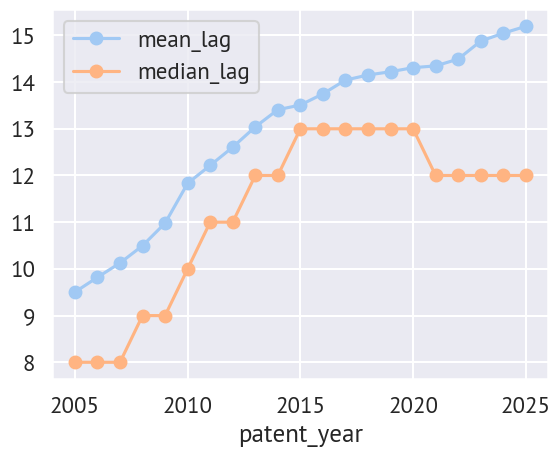

In [8]:
time_delta_plots_df.plot.line(x='patent_year', y=['mean_lag', 'median_lag'], marker='o')

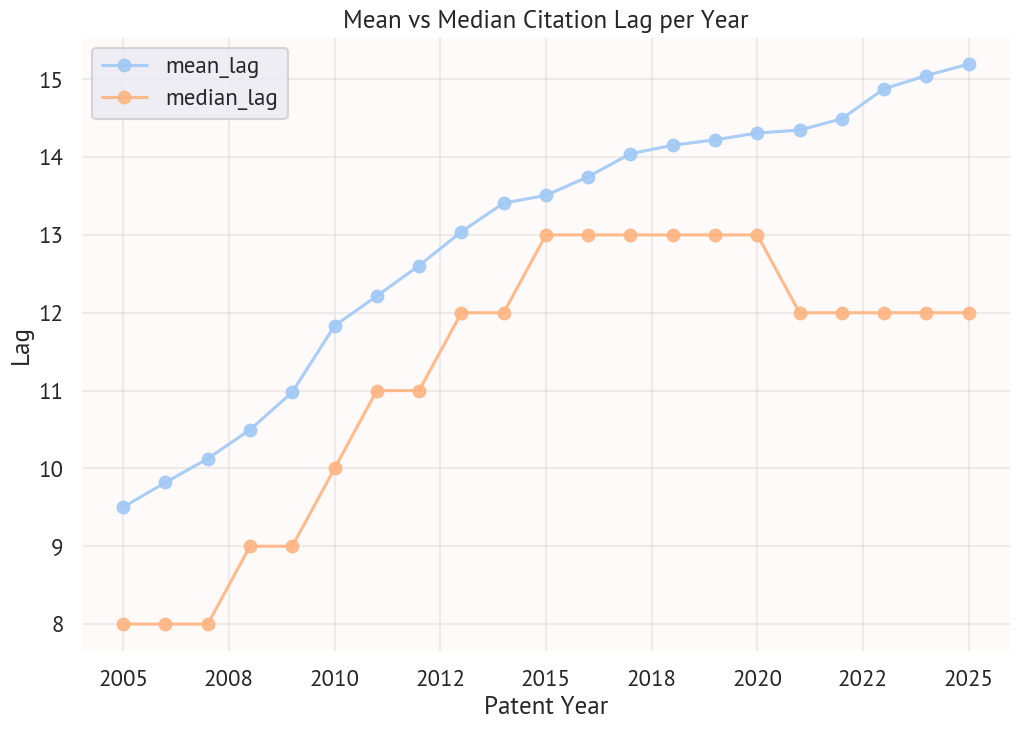

In [94]:
ax = time_delta_plots_df.plot.line(
    x='patent_year',
    y=['mean_lag', 'median_lag'],
    marker='o',
    figsize=(12, 8),
    color=[(0.63, 0.79, 0.96), (1.0, 0.71, 0.51)],
    alpha=0.9
)

# Match your previous styling
ax.set_facecolor('snow')
ax.grid(alpha=0.4, color='lightgrey')

# Optional: match title + labels styling
ax.set_title('Mean vs Median Citation Lag per Year')
ax.set_xlabel('Patent Year')
ax.set_ylabel('Lag')
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))

# Clean ticks like before
from matplotlib.ticker import ScalarFormatter


plt.show()

In [ ]:
#bar plot sns sns.barplot that will generate the bar plot specify which column 

In [5]:
time_delta_plots_df

,patent_year,mean_lag,median_lag
0,2025.0,15.194977,12.0
1,2024.0,15.046980,12.0
2,2023.0,14.877797,12.0
3,2022.0,14.492379,12.0
4,2021.0,14.346651,12.0
5,2020.0,14.308960,13.0
6,2019.0,14.221931,13.0
7,2018.0,14.152199,13.0
8,2017.0,14.043141,13.0
9,2016.0,13.747810,13.0


In [9]:
sql = '''
SELECT c.patent_id, c.cpc_subclass
FROM g_cpc_current c
JOIN g_patent p ON c.patent_id = p.patent_id
WHERE c.cpc_sequence = 0 AND EXTRACT(YEAR FROM p.patent_date) > 2004;
'''

pd.read_sql(text(sql), engine)

,patent_id,cpc_subclass
0,6850621,H04S
1,6852660,C08F
2,6900014,C12N
3,6852772,C08J
4,6900116,H01L
...,...,...
5541416,11888156,H01M
5541417,11794389,B29C
5541418,12019454,B60W
5541419,12208740,B60R


In [11]:
sql = """
SELECT p.patent_id
FROM g_patent p
WHERE EXTRACT(YEAR FROM p.patent_date) > 2004;
"""

pd.read_sql(text(sql), engine)

,patent_id
0,10000000
1,10000001
2,10000002
3,10000003
4,10000004
...,...
6187999,RE50611
6188000,RE50612
6188001,RE50613
6188002,RE50614


In [2]:
sql = '''
SELECT d.*, c.cpc_subclass
FROM patent_citation_year_diff d
JOIN g_cpc_current c ON d.patent_id = c.patent_id
WHERE c.cpc_sequence = 0
LIMIT 40;
'''

pd.read_sql(text(sql), engine)

,patent_id,citation_sequence,citation_patent_id,patent_year,cited_patent_year,year_diff,cpc_subclass
0,10000000,0,5093563,2018.0,1992.0,26.0,G01S
1,10000000,1,5751830,2018.0,1998.0,20.0,G01S
2,10000001,3,9108352,2018.0,2015.0,3.0,B29C
3,10000001,4,9296144,2018.0,2016.0,2.0,B29C
4,10000001,5,9566732,2018.0,2017.0,1.0,B29C
5,10000001,1,9022767,2018.0,2015.0,3.0,B29C
6,10000001,0,7804268,2018.0,2010.0,8.0,B29C
7,10000001,2,9090016,2018.0,2015.0,3.0,B29C
8,10000002,2,8124241,2018.0,2012.0,6.0,B29C
9,10000002,1,5094793,2018.0,1992.0,26.0,B29C


In [ ]:
sql = '''
SELECT sub.cpc_subclass,
       t.cpc_subclass_title,
       AVG(sub.year_diff) AS mean_lag,
       PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY sub.year_diff) AS median_lag
FROM (
    SELECT d.year_diff,
           c.cpc_subclass
    FROM patent_citation_year_diff d
    JOIN g_cpc_current c 
        ON d.patent_id = c.patent_id
    WHERE c.cpc_sequence = 0
) AS sub
JOIN g_cpc_title t
    ON sub.cpc_subclass = t.cpc_subclass
GROUP BY sub.cpc_subclass, t.cpc_subclass_title
ORDER BY sub.cpc_subclass;
'''
cpc_subclass_means_df = pd.read_sql(text(sql), engine)

In [2]:
sql = '''
WITH titles AS (
    SELECT DISTINCT ON (cpc_subclass) 
           cpc_subclass, 
           cpc_subclass_title
    FROM g_cpc_title
)
SELECT sub.cpc_subclass,
       t.cpc_subclass_title,
       AVG(sub.year_diff) AS mean_lag,
       PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY sub.year_diff) AS median_lag
FROM (
    SELECT d.year_diff,
           c.cpc_subclass
    FROM patent_citation_year_diff d
    JOIN g_cpc_current c 
        ON d.patent_id = c.patent_id
    WHERE c.cpc_sequence = 0
) AS sub
JOIN titles t
    ON sub.cpc_subclass = t.cpc_subclass
GROUP BY sub.cpc_subclass, t.cpc_subclass_title
ORDER BY sub.cpc_subclass;
'''

cpc_subclass_means_df = pd.read_sql(text(sql), engine)

In [3]:
cpc_subclass_means_df.to_parquet('../parquets/cpcsubclassmeansdf.parquet')

In [4]:
cpc_subclass_means_df =pd.read_parquet('../parquets/cpcsubclassmeansdf.parquet')
cpc_subclass_means_df

,cpc_subclass,cpc_subclass_title,mean_lag,median_lag
0,A01B,SOIL WORKING IN AGRICULTURE OR FORESTRY; PARTS...,17.196352,15.0
1,A01C,PLANTING; SOWING; FERTILISING,16.441065,14.0
2,A01D,HARVESTING; MOWING,17.118014,15.0
3,A01F,PROCESSING OF HARVESTED PRODUCE; HAY OR STRAW ...,18.440307,17.0
4,A01G,"HORTICULTURE; CULTIVATION OF VEGETABLES, FLOWE...",17.488308,16.0
...,...,...,...,...
633,H10D,INORGANIC ELECTRIC SEMICONDUCTOR DEVICES,10.460230,9.0
634,H10F,INORGANIC SEMICONDUCTOR DEVICES SENSITIVE TO I...,13.569798,11.0
635,H10H,INORGANIC LIGHT-EMITTING SEMICONDUCTOR DEVICES...,10.389074,9.0
636,H10K,ORGANIC ELECTRIC SOLID-STATE DEVICES,10.327354,9.0


In [5]:
# Top 5 CPC subclasses with the HIGHEST average lag
top5_most_lag = (
    cpc_subclass_means_df
    .nlargest(5, 'mean_lag')
    .reset_index(drop=True)
)
top5_most_lag

,cpc_subclass,cpc_subclass_title,mean_lag,median_lag
0,C10F,DRYING OR WORKING-UP OF PEAT,33.500000,35.5
1,C06F,MATCHES; MANUFACTURE OF MATCHES,29.666667,31.0
2,C09F,NATURAL RESINS; FRENCH POLISH; DRYING-OILS; OI...,24.645161,27.0
3,C10B,DESTRUCTIVE DISTILLATION OF CARBONACEOUS MATER...,23.844867,24.0
4,G21C,NUCLEAR REACTORS,22.608297,23.0


In [6]:
# Top 5 CPC subclasses with the LOWEST average lag
top5_least_lag = (
    cpc_subclass_means_df
    .nsmallest(5, 'mean_lag')
    .reset_index(drop=True)
)
top5_least_lag

,cpc_subclass,cpc_subclass_title,mean_lag,median_lag
0,G16Y,INFORMATION AND COMMUNICATION TECHNOLOGY SPECI...,5.655172,3.0
1,C12Y,ENZYMES,7.363636,7.0
2,B41D,APPARATUS FOR THE MECHANICAL REPRODUCTION OF P...,9.033333,7.0
3,G11B,INFORMATION STORAGE BASED ON RELATIVE MOVEMENT...,9.529159,8.0
4,H03L,"AUTOMATIC CONTROL, STARTING, SYNCHRONISATION O...",9.753003,8.0


In [41]:
wanted = ['G06F', 'H04L', 'A61B', 'H04N', 'H01L']

filtered_df = cpc_subclass_means_df[
    cpc_subclass_means_df['cpc_subclass'].isin(wanted)
]

filtered_df

,cpc_subclass,mean_lag,median_lag
59,A61B,14.838431,13.0
537,G06F,10.850055,10.0
589,H01L,12.416938,11.0
619,H04L,10.164058,9.0
621,H04N,12.584777,11.0


In [36]:
sql = '''
SELECT DISTINCT ON (cpc_subclass)
    cpc_subclass,
    cpc_subclass_title
FROM g_cpc_title;
'''
subclass_titles_df = pd.read_sql(text(sql), engine)
subclass_titles_df

,cpc_subclass,cpc_subclass_title
0,A01B,SOIL WORKING IN AGRICULTURE OR FORESTRY; PARTS...
1,A01C,PLANTING; SOWING; FERTILISING
2,A01D,HARVESTING; MOWING
3,A01F,PROCESSING OF HARVESTED PRODUCE; HAY OR STRAW ...
4,A01G,"HORTICULTURE; CULTIVATION OF VEGETABLES, FLOWE..."
...,...,...
676,Y02T,CLIMATE CHANGE MITIGATION TECHNOLOGIES RELATED...
677,Y02W,CLIMATE CHANGE MITIGATION TECHNOLOGIES RELATED...
678,Y04S,SYSTEMS INTEGRATING TECHNOLOGIES RELATED TO PO...
679,Y10S,TECHNICAL SUBJECTS COVERED BY FORMER USPC CROS...


In [8]:
import re

def smart_cpc_title(text):
    # split into words
    words = text.split()
    
    cleaned = []
    for w in words:
        # keep things like H10, A61B, G06F unchanged
        if re.match(r'^[A-Z]\d+[A-Z]?$|^[A-Z]\d+$', w):
            cleaned.append(w)
        else:
            cleaned.append(w.capitalize())
    
    return " ".join(cleaned)

In [9]:
top5_most_lag['cpc_subclass_title'] = (
    top5_most_lag['cpc_subclass_title']
    .str.lower()
    .apply(smart_cpc_title)
)

top5_most_lag

,cpc_subclass,cpc_subclass_title,mean_lag,median_lag
0,C10F,Drying Or Working-up Of Peat,33.500000,35.5
1,C06F,Matches; Manufacture Of Matches,29.666667,31.0
2,C09F,Natural Resins; French Polish; Drying-oils; Oi...,24.645161,27.0
3,C10B,Destructive Distillation Of Carbonaceous Mater...,23.844867,24.0
4,G21C,Nuclear Reactors,22.608297,23.0


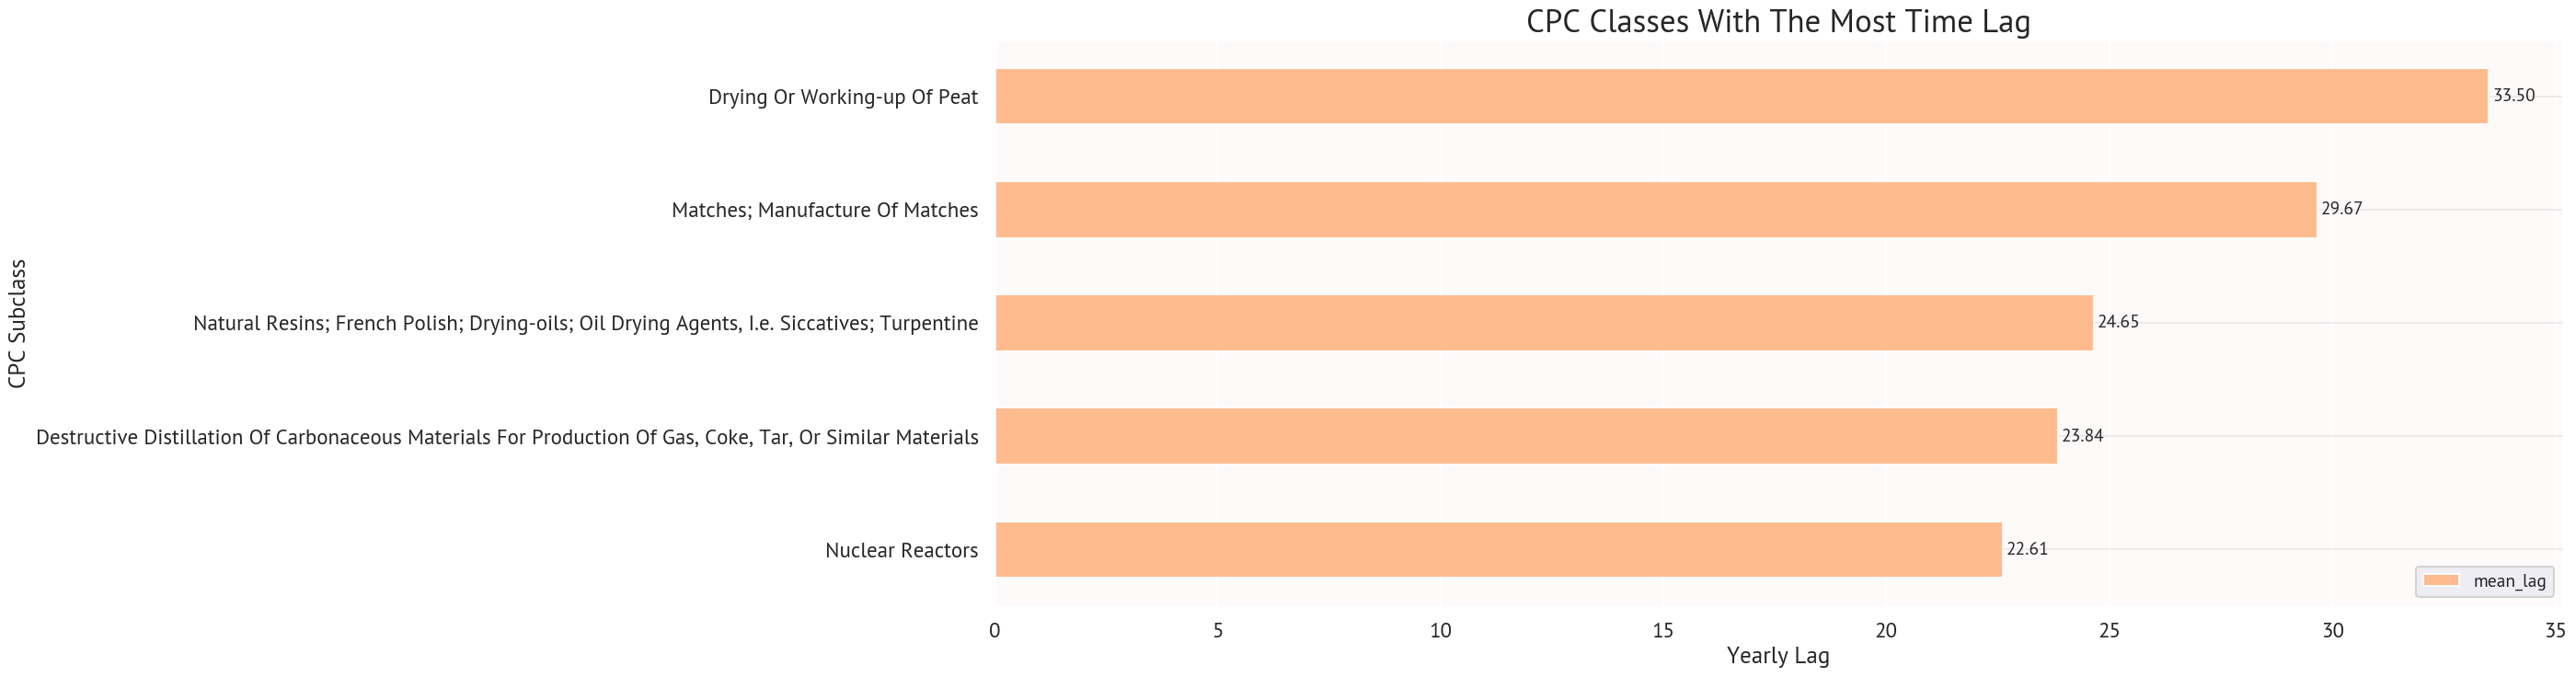

In [22]:
ax = top5_most_lag.plot.barh(
    x='cpc_subclass_title',
    y='mean_lag',
    figsize=(22, 8),
    color=(1.0, 0.71, 0.51),
    alpha=0.9
)

# Match your style
ax.set_facecolor('snow')
ax.grid(axis='y', alpha=0.4, color='lightgrey')

# Title and labels
ax.set_title('CPC Classes With The Most Time Lag', fontsize=25)
ax.set_xlabel('Yearly Lag')
ax.set_ylabel('CPC Subclass')
ax.invert_yaxis()

# Fix x labels (they often overlap)
#ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
# Clean legend
ax.legend(loc='best', fontsize=14)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',   # 2 decimal places
        padding=3,
        fontsize=14
    )

#plt.tight_layout()
fig = ax.figure
fig.savefig('../figures/most_time__lag.png', dpi=300, bbox_inches='tight', transparent=True)

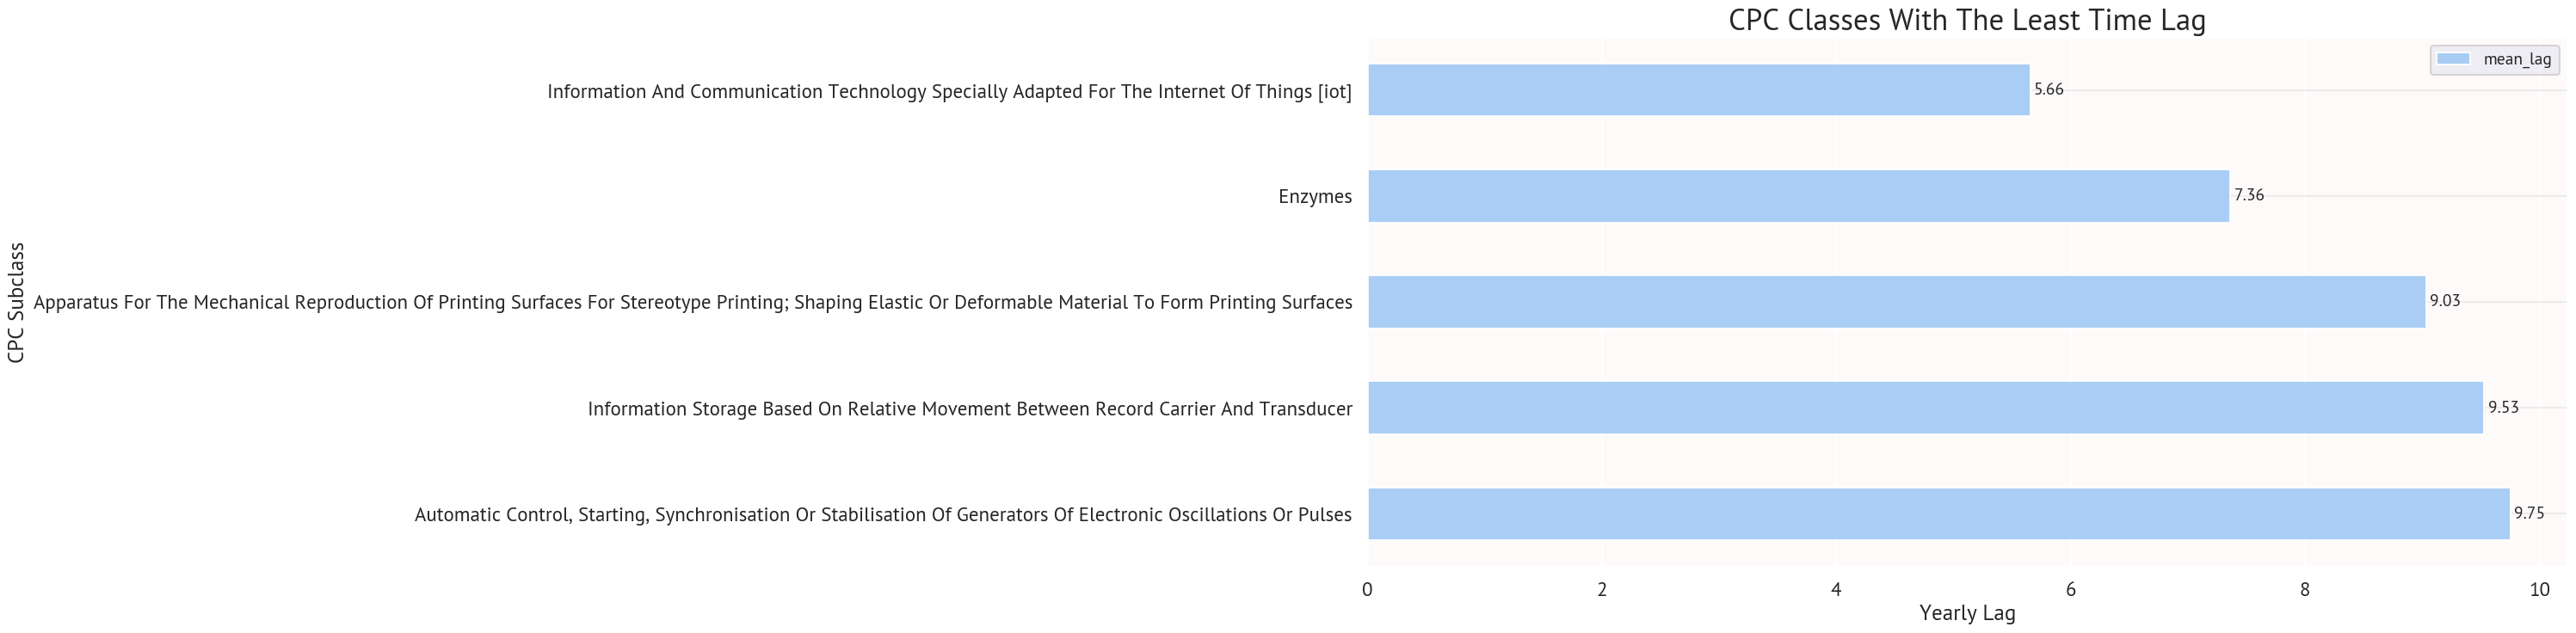

In [21]:
ax = top5_least_lag.plot.barh(
    x='cpc_subclass_title',
    y='mean_lag',
    figsize=(18, 8),
    color=(0.63, 0.79, 0.96),
    alpha=0.9
)

# Match your style
ax.set_facecolor('snow')
ax.grid(axis='y', alpha=0.4, color='lightgrey')

# Title and labels
ax.set_title('CPC Classes With The Least Time Lag', fontsize=25)
ax.set_xlabel('Yearly Lag')
ax.set_ylabel('CPC Subclass')
ax.invert_yaxis()

# Fix x labels (they often overlap)
#ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
# Clean legend
ax.legend(loc='best', fontsize=14)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',   # 2 decimal places
        padding=3,
        fontsize=14
    )

#plt.tight_layout()
fig = ax.figure
fig.savefig('../figures/least_time__lag.png', dpi=300, bbox_inches='tight', transparent=True)

In [10]:
top5_least_lag['cpc_subclass_title'] = (
    top5_least_lag['cpc_subclass_title']
    .str.lower()
    .apply(smart_cpc_title)
)

top5_most_lag

,cpc_subclass,cpc_subclass_title,mean_lag,median_lag
0,C10F,Drying Or Working-up Of Peat,33.500000,35.5
1,C06F,Matches; Manufacture Of Matches,29.666667,31.0
2,C09F,Natural Resins; French Polish; Drying-oils; Oi...,24.645161,27.0
3,C10B,Destructive Distillation Of Carbonaceous Mater...,23.844867,24.0
4,G21C,Nuclear Reactors,22.608297,23.0


In [79]:
subclass_titles_df['cpc_subclass_title'] = (
    subclass_titles_df['cpc_subclass_title']
    .str.lower()
    .apply(smart_cpc_title)
)

subclass_titles_df

,cpc_subclass,cpc_subclass_title
0,A61B,Diagnosis; Surgery; Identification
1,G06F,Electric Digital Data Processing
2,H01L,Semiconductor Devices Not Covered By Class H10
3,H04L,"Transmission Of Digital Information, E.g. Tele..."
4,H04N,"Pictorial Communication, E.g. Television"


In [80]:
filtered_df_with_title = (
    pd.merge(
        filtered_df,
        subclass_titles_df,
        on='cpc_subclass',
        how='inner'
    )
)
filtered_df_with_title


,cpc_subclass,mean_lag,median_lag,cpc_subclass_title
0,A61B,14.838431,13.0,Diagnosis; Surgery; Identification
1,G06F,10.850055,10.0,Electric Digital Data Processing
2,H01L,12.416938,11.0,Semiconductor Devices Not Covered By Class H10
3,H04L,10.164058,9.0,"Transmission Of Digital Information, E.g. Tele..."
4,H04N,12.584777,11.0,"Pictorial Communication, E.g. Television"


[(0.63, 0.79, 0.96), (1.0, 0.71, 0.51), (0.55, 0.9, 0.63), (1.0, 0.62, 0.61), (0.82, 0.73, 1.0), (0.87, 0.73, 0.61), (0.98, 0.69, 0.89), (0.81, 0.81, 0.81), (1.0, 1.0, 0.64), (0.73, 0.95, 0.94)]


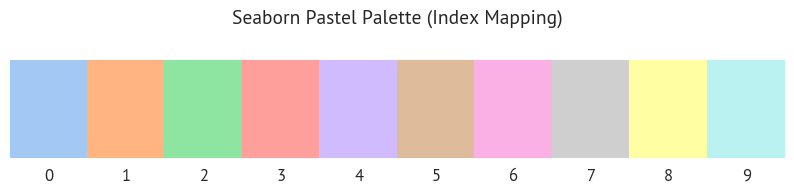

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = sns.color_palette("pastel")

# RGB list
rgb_list = [tuple(round(x, 2) for x in c) for c in palette]
print(rgb_list)

fig, ax = plt.subplots(figsize=(10, 2))

for i, color in enumerate(palette):
    # color square
    ax.add_patch(
        plt.Rectangle((i, 0.3), 1, 1, color=color)
    )
    
    # index label
    ax.text(
        i + 0.5, 0.1,
        str(i),
        ha='center',
        va='center',
        fontsize=12
    )

ax.set_xlim(0, len(palette))
ax.set_ylim(0, 1.6)
ax.axis('off')

ax.set_title("Seaborn Pastel Palette (Index Mapping)", fontsize=14)

plt.show()

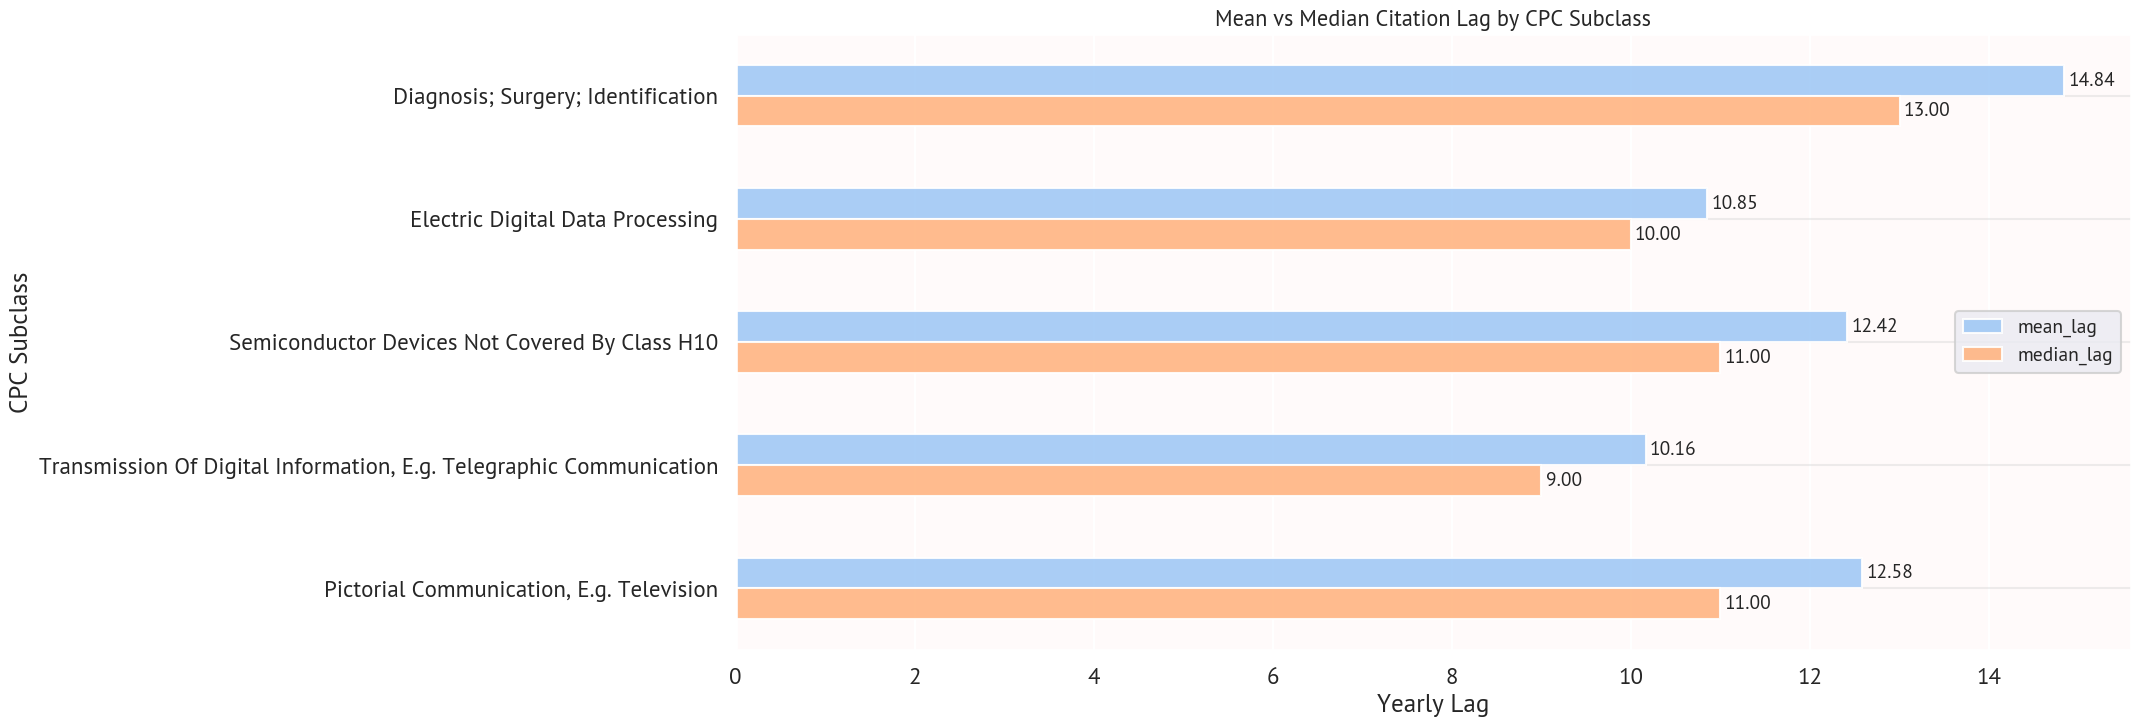

In [104]:
ax = filtered_df_with_title.plot.barh(
    x='cpc_subclass_title',
    y=['mean_lag', 'median_lag'],
    figsize=(18, 8),
    color=[(0.63, 0.79, 0.96), (1.0, 0.71, 0.51)],
    alpha=0.9
)

# Match your style
ax.set_facecolor('snow')
ax.grid(axis='y', alpha=0.4, color='lightgrey')

# Title and labels
ax.set_title('Mean vs Median Citation Lag by CPC Subclass', fontsize=16)
ax.set_xlabel('Yearly Lag')
ax.set_ylabel('CPC Subclass')
ax.invert_yaxis()

# Fix x labels (they often overlap)
#ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
# Clean legend
ax.legend(loc='center right', fontsize=14)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',   # 2 decimal places
        padding=3,
        fontsize=14
    )

#plt.tight_layout()
fig = ax.figure


#fig.savefig('../figures/subclass_citation_lag.png', dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
degree_with_cpc_df

top_subclasses = (
    degree_with_cpc_df
    .cpc_subclass
    .value_counts()
    .head(5)
    .index
    .tolist()
)


ax = filtered_df.plot.bar(
    x='cpc_subclass',
    y=['mean_lag', 'median_lag'],
    figsize=(12, 6),
    color=['steelblue', 'darkorange'],
    alpha=0.7
)

# Match your style
ax.set_facecolor('snow')
ax.grid(axis='y', alpha=0.4, color='lightgrey')

# Title and labels
ax.set_title('Mean vs Median Citation Lag by CPC Subclass', fontsize=16)
ax.set_xlabel('CPC Subclass')
ax.set_ylabel('Lag')

# Fix x labels (they often overlap)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Clean legend
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()-

In [27]:
degree_with_cpc_df = pd.read_parquet('../parquets/patents_degree_info_2_2005.parquet')
degree_with_cpc_df

,patent_id,num_references,year,num_citations,cpc_class,cpc_subclass
0,10000000,2,2018,19.0,G01,G01S
1,10000001,6,2018,0.0,B29,B29C
2,10000002,3,2018,0.0,B29,B29C
3,10000003,4,2018,2.0,B29,B29C
4,10000004,2,2018,0.0,B29,B29C
...,...,...,...,...,...,...
4882287,9999995,6,2018,0.0,B29,B29C
4882288,9999996,4,2018,2.0,B29,B29C
4882289,9999997,14,2018,0.0,B29,B29C
4882290,9999998,1,2018,0.0,B29,B29C


In [29]:
wanted = ['G06F', 'H04L', 'A61B', 'H04N', 'H01L']

top5_per_subclass = (
    degree_with_cpc_df[
        degree_with_cpc_df['cpc_subclass'].isin(wanted)
    ]
    .sort_values(['cpc_subclass', 'num_citations'], ascending=[True, False])
    .groupby('cpc_subclass')
    .head(5)
)

top5_per_subclass

,patent_id,num_references,year,num_citations,cpc_class,cpc_subclass
2511960,7380695,34,2008,3304.0,A61,A61B
2534850,7404508,12,2008,3300.0,A61,A61B
2143814,7000818,22,2006,3243.0,A61,A61B
2125072,6981628,24,2006,3184.0,A61,A61B
2511961,7380696,37,2008,3153.0,A61,A61B
2783010,7663607,166,2010,3274.0,G06,G06F
1989252,6842748,3,2005,2140.0,G06,G06F
3544922,8479122,469,2013,1959.0,G06,G06F
2607441,7479949,12,2009,1853.0,G06,G06F
3320490,8234395,43,2012,1790.0,G06,G06F


In [30]:
degree_with_cpc_df

,patent_id,num_references,year,num_citations,cpc_class,cpc_subclass
0,10000000,2,2018,19.0,G01,G01S
1,10000001,6,2018,0.0,B29,B29C
2,10000002,3,2018,0.0,B29,B29C
3,10000003,4,2018,2.0,B29,B29C
4,10000004,2,2018,0.0,B29,B29C
...,...,...,...,...,...,...
4882287,9999995,6,2018,0.0,B29,B29C
4882288,9999996,4,2018,2.0,B29,B29C
4882289,9999997,14,2018,0.0,B29,B29C
4882290,9999998,1,2018,0.0,B29,B29C


In [34]:
avg_year_by_subclass_df = (
    degree_with_cpc_df[
        degree_with_cpc_df['cpc_subclass'].isin(wanted)
    ]
    .groupby('cpc_subclass', as_index=False)['year']
    .mean()
    .sort_values('year', ascending=False)
)

avg_year_by_subclass_df

,cpc_subclass,year
0,A61B,2017.200672
1,G06F,2016.586487
3,H04L,2016.204461
4,H04N,2015.470948
2,H01L,2015.141996


In [36]:
filtered_df

,cpc_subclass,mean_lag,median_lag
59,A61B,14.838431,13.0
537,G06F,10.850055,10.0
589,H01L,12.416938,11.0
619,H04L,10.164058,9.0
621,H04N,12.584777,11.0


In [40]:
joined_df = (
    pd.merge(
        filtered_df,
        avg_year_by_subclass_df,
        on='cpc_subclass',
        how='inner'
    )
    .rename(columns={'year': 'avg_year_patents_filed'})-+
)

joined_df

,cpc_subclass,mean_lag,median_lag,avg_year_patents_filed
0,A61B,14.838431,13.0,2017.200672
1,G06F,10.850055,10.0,2016.586487
2,H01L,12.416938,11.0,2015.141996
3,H04L,10.164058,9.0,2016.204461
4,H04N,12.584777,11.0,2015.470948


In [4]:
patents_info_df = pd.read_parquet('../parquets/patents_degree_info_2_2005.parquet')
patents_info_df

,patent_id,num_references,year,num_citations,cpc_class,cpc_subclass
0,10000000,2,2018,19.0,G01,G01S
1,10000001,6,2018,0.0,B29,B29C
2,10000002,3,2018,0.0,B29,B29C
3,10000003,4,2018,2.0,B29,B29C
4,10000004,2,2018,0.0,B29,B29C
...,...,...,...,...,...,...
4882287,9999995,6,2018,0.0,B29,B29C
4882288,9999996,4,2018,2.0,B29,B29C
4882289,9999997,14,2018,0.0,B29,B29C
4882290,9999998,1,2018,0.0,B29,B29C


In [7]:
df_by_year = patents_info_df.groupby('year')['patent_id'].count().sort_index(ascending=True).reset_index(name='num_patents')
df_by_year

,year,num_patents
0,2005,141221
1,2006,169837
2,2007,152895
3,2008,152735
4,2009,160849
5,2010,209868
6,2011,212463
7,2012,235884
8,2013,255616
9,2014,273465


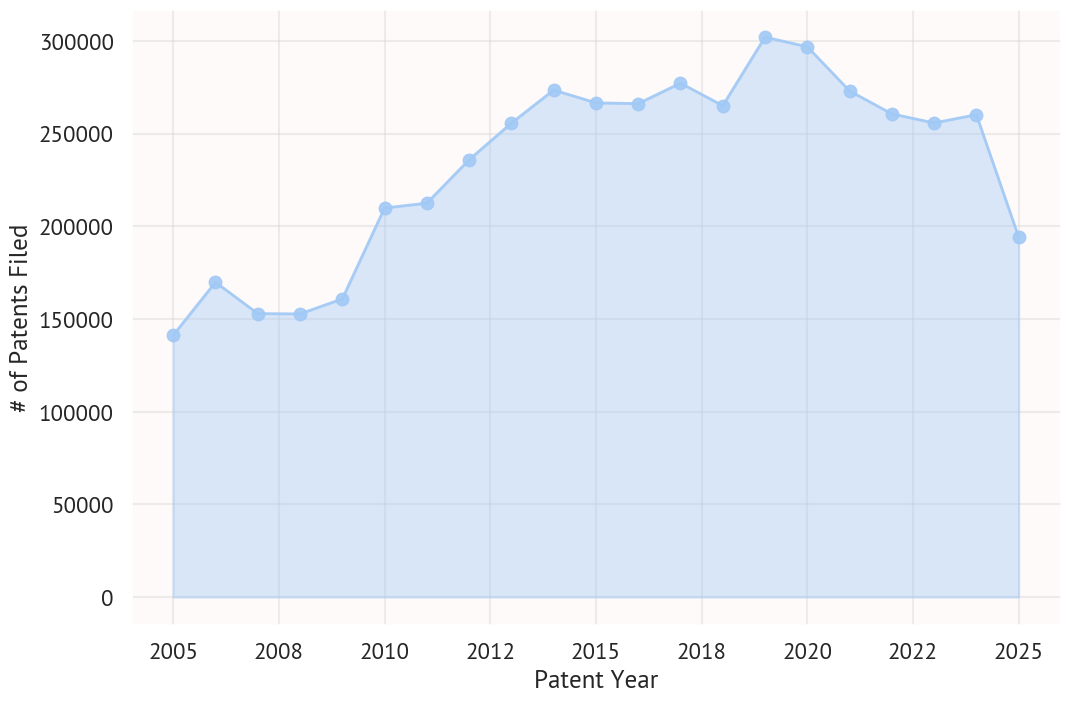

In [17]:
fig, ax = plt.subplots(figsize=(12, 8))

# Filled area under the line
ax.fill_between(
    df_by_year['year'],
    df_by_year['num_patents'],
    color=(0.63, 0.79, 0.96),
    alpha=0.4
)

# Line on top with markers
ax.plot(
    df_by_year['year'],
    df_by_year['num_patents'],
    marker='o',
    color=(0.63, 0.79, 0.96),
    alpha=0.9,
    linewidth=2
)

# Styling to match your previous plots
ax.set_facecolor('snow')
ax.grid(alpha=0.4, color='lightgrey')
ax.set_xlabel('Patent Year')
ax.set_ylabel('# of Patents Filed')
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:.0f}'))

fig = ax.figure
fig.savefig('../figures/yearly_patents.png', dpi=300, bbox_inches='tight', transparent=True)

In [18]:
patents_info_df

,patent_id,num_references,year,num_citations,cpc_class,cpc_subclass
0,10000000,2,2018,19.0,G01,G01S
1,10000001,6,2018,0.0,B29,B29C
2,10000002,3,2018,0.0,B29,B29C
3,10000003,4,2018,2.0,B29,B29C
4,10000004,2,2018,0.0,B29,B29C
...,...,...,...,...,...,...
4882287,9999995,6,2018,0.0,B29,B29C
4882288,9999996,4,2018,2.0,B29,B29C
4882289,9999997,14,2018,0.0,B29,B29C
4882290,9999998,1,2018,0.0,B29,B29C


In [29]:
cpc_titles_df = pd.read_parquet('../parquets/dfwithcpctitles.parquet')

cpc_titles_df

,patent_id,num_references,year,num_citations,cpc_class,cpc_subclass,cpc_subclass_title_x,cpc_class_title_x,cpc_subclass_title_y,cpc_class_title_y
0,10000000,2,2018,19.0,G01,G01S,RADIO DIRECTION-FINDING; RADIO NAVIGATION; DET...,MEASURING; TESTING,RADIO DIRECTION-FINDING; RADIO NAVIGATION; DET...,MEASURING; TESTING
1,10000001,6,2018,0.0,B29,B29C,SHAPING OR JOINING OF PLASTICS; SHAPING OF MAT...,WORKING OF PLASTICS; WORKING OF SUBSTANCES IN ...,SHAPING OR JOINING OF PLASTICS; SHAPING OF MAT...,WORKING OF PLASTICS; WORKING OF SUBSTANCES IN ...
2,10000002,3,2018,0.0,B29,B29C,SHAPING OR JOINING OF PLASTICS; SHAPING OF MAT...,WORKING OF PLASTICS; WORKING OF SUBSTANCES IN ...,SHAPING OR JOINING OF PLASTICS; SHAPING OF MAT...,WORKING OF PLASTICS; WORKING OF SUBSTANCES IN ...
3,10000003,4,2018,2.0,B29,B29C,SHAPING OR JOINING OF PLASTICS; SHAPING OF MAT...,WORKING OF PLASTICS; WORKING OF SUBSTANCES IN ...,SHAPING OR JOINING OF PLASTICS; SHAPING OF MAT...,WORKING OF PLASTICS; WORKING OF SUBSTANCES IN ...
4,10000004,2,2018,0.0,B29,B29C,SHAPING OR JOINING OF PLASTICS; SHAPING OF MAT...,WORKING OF PLASTICS; WORKING OF SUBSTANCES IN ...,SHAPING OR JOINING OF PLASTICS; SHAPING OF MAT...,WORKING OF PLASTICS; WORKING OF SUBSTANCES IN ...
...,...,...,...,...,...,...,...,...,...,...
4882287,9999995,6,2018,0.0,B29,B29C,SHAPING OR JOINING OF PLASTICS; SHAPING OF MAT...,WORKING OF PLASTICS; WORKING OF SUBSTANCES IN ...,SHAPING OR JOINING OF PLASTICS; SHAPING OF MAT...,WORKING OF PLASTICS; WORKING OF SUBSTANCES IN ...
4882288,9999996,4,2018,2.0,B29,B29C,SHAPING OR JOINING OF PLASTICS; SHAPING OF MAT...,WORKING OF PLASTICS; WORKING OF SUBSTANCES IN ...,SHAPING OR JOINING OF PLASTICS; SHAPING OF MAT...,WORKING OF PLASTICS; WORKING OF SUBSTANCES IN ...
4882289,9999997,14,2018,0.0,B29,B29C,SHAPING OR JOINING OF PLASTICS; SHAPING OF MAT...,WORKING OF PLASTICS; WORKING OF SUBSTANCES IN ...,SHAPING OR JOINING OF PLASTICS; SHAPING OF MAT...,WORKING OF PLASTICS; WORKING OF SUBSTANCES IN ...
4882290,9999998,1,2018,0.0,B29,B29C,SHAPING OR JOINING OF PLASTICS; SHAPING OF MAT...,WORKING OF PLASTICS; WORKING OF SUBSTANCES IN ...,SHAPING OR JOINING OF PLASTICS; SHAPING OF MAT...,WORKING OF PLASTICS; WORKING OF SUBSTANCES IN ...


In [33]:
print(pd.read_parquet('../parquets/patents_degree_info_2_2005.parquet'))

        patent_id  num_references  year  num_citations cpc_class cpc_subclass
0        10000000               2  2018           19.0       G01         G01S
1        10000001               6  2018            0.0       B29         B29C
2        10000002               3  2018            0.0       B29         B29C
3        10000003               4  2018            2.0       B29         B29C
4        10000004               2  2018            0.0       B29         B29C
...           ...             ...   ...            ...       ...          ...
4882287   9999995               6  2018            0.0       B29         B29C
4882288   9999996               4  2018            2.0       B29         B29C
4882289   9999997              14  2018            0.0       B29         B29C
4882290   9999998               1  2018            0.0       B29         B29C
4882291   9999999               2  2018            2.0       B29         B29C

[4882292 rows x 6 columns]


In [32]:
mask = cpc_titles_df['year'].between(2009, 2014)

top5_per_year = (
    cpc_titles_df[mask]
    .groupby(['year', 'cpc_subclass', 'cpc_subclass_title_x'])
    .size()
    .reset_index(name='num_patents')
    .sort_values(['year', 'num_patents'], ascending=[True, False])
    .groupby('year')
    .head(5)
    .reset_index(drop=True)
)

top5_per_year

,year,cpc_subclass,cpc_subclass_title_x,num_patents
0,2009,G06F,ELECTRIC DIGITAL DATA PROCESSING,13496
1,2009,H04L,"TRANSMISSION OF DIGITAL INFORMATION, e.g. TELE...",8443
2,2009,H04N,"PICTORIAL COMMUNICATION, e.g. TELEVISION",5110
3,2009,H01L,SEMICONDUCTOR DEVICES NOT COVERED BY CLASS H10,4552
4,2009,G11B,INFORMATION STORAGE BASED ON RELATIVE MOVEMENT...,3359
5,2010,G06F,ELECTRIC DIGITAL DATA PROCESSING,17572
6,2010,H04L,"TRANSMISSION OF DIGITAL INFORMATION, e.g. TELE...",11240
7,2010,H04N,"PICTORIAL COMMUNICATION, e.g. TELEVISION",6321
8,2010,H01L,SEMICONDUCTOR DEVICES NOT COVERED BY CLASS H10,5811
9,2010,G06Q,INFORMATION AND COMMUNICATION TECHNOLOGY [ICT]...,5520
